In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('matches_1930_2022.csv')

In [3]:
df.head()

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [4]:
df.shape

(964, 44)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   home_team                        964 non-null    object 
 1   away_team                        964 non-null    object 
 2   home_score                       964 non-null    int64  
 3   home_xg                          128 non-null    float64
 4   home_penalty                     35 non-null     float64
 5   away_score                       964 non-null    int64  
 6   away_xg                          128 non-null    float64
 7   away_penalty                     35 non-null     float64
 8   home_manager                     964 non-null    object 
 9   home_captain                     644 non-null    object 
 10  away_manager                     964 non-null    object 
 11  away_captain                     644 non-null    object 
 12  Attendance            

In [6]:
df.describe()

,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,Attendance,Year
count,964.000000,128.000000,35.000000,964.000000,128.000000,35.000000,964.000000,964.000000
mean,1.776971,1.435938,3.285714,1.044606,1.192187,3.057143,45693.374481,1989.244813
std,1.596676,0.860391,1.226459,1.071233,0.809258,1.136115,22704.131689,24.014409
min,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,2000.000000,1930.000000
25%,1.000000,0.800000,3.000000,0.000000,0.600000,2.000000,31800.000000,1974.000000
50%,1.000000,1.300000,3.000000,1.000000,1.000000,3.000000,42725.000000,1994.000000
75%,3.000000,1.925000,4.000000,2.000000,1.525000,4.000000,60984.500000,2010.000000
max,10.000000,5.200000,5.000000,7.000000,5.700000,5.000000,173850.000000,2022.000000


In [7]:
missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_df = missing_df.sort_values('Percentage', ascending=False)
print(missing_df)

                                 Missing Values  Percentage
home_penalty_miss_long                      958   99.377593
away_penalty_miss_long                      955   99.066390
away_own_goal                               947   98.236515
home_yellow_red_card                        941   97.614108
home_penalty_shootout_miss_long             940   97.510373
away_penalty_shootout_miss_long             934   96.887967
away_yellow_red_card                        933   96.784232
home_penalty_shootout_goal_long             930   96.473029
away_penalty_shootout_goal_long             930   96.473029
home_penalty                                929   96.369295
away_penalty                                929   96.369295
home_own_goal                               925   95.954357
home_red_card                               913   94.709544
away_red_card                               910   94.398340
Notes                                       891   92.427386
away_penalty_goal                       

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.corr(numeric_only = True)

,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,Attendance,Year
home_score,1.000000,0.621172,0.292306,0.005215,-0.133290,0.162664,-0.095617,-0.339134
home_xg,0.621172,1.000000,0.222424,0.037534,-0.266932,-0.162696,0.007194,-0.063811
home_penalty,0.292306,0.222424,1.000000,0.292306,0.466900,-0.012062,0.026898,-0.154670
away_score,0.005215,0.037534,0.292306,1.000000,0.475121,0.162664,-0.036464,0.078814
away_xg,-0.133290,-0.266932,0.466900,0.475121,1.000000,0.208576,-0.071096,0.096918
away_penalty,0.162664,-0.162696,-0.012062,0.162664,0.208576,1.000000,0.076311,-0.270397
Attendance,-0.095617,0.007194,0.026898,-0.036464,-0.071096,0.076311,1.000000,0.297490
Year,-0.339134,-0.063811,-0.154670,0.078814,0.096918,-0.270397,0.297490,1.000000


In [10]:
df.columns

Index(['home_team', 'away_team', 'home_score', 'home_xg', 'home_penalty',
       'away_score', 'away_xg', 'away_penalty', 'home_manager', 'home_captain',
       'away_manager', 'away_captain', 'Attendance', 'Venue', 'Officials',
       'Round', 'Date', 'Score', 'Referee', 'Notes', 'Host', 'Year',
       'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long',
       'home_own_goal', 'away_own_goal', 'home_penalty_goal',
       'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long',
       'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long',
       'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long',
       'home_red_card', 'away_red_card', 'home_yellow_red_card',
       'away_yellow_red_card', 'home_yellow_card_long',
       'away_yellow_card_long', 'home_substitute_in_long',
       'away_substitute_in_long'],
      dtype='object')

In [11]:
columns_to_drop = ['Score', 'Notes', 'Referee', 'Officials', 'home_manager', 'away_manager', 'home_captain', 'away_captain', 'home_goal',
                   'away_goal', 'home_goal_long', 'away_goal_long', 'home_penalty_miss_long', 'away_penalty_miss_long',
                   'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long', 'home_penalty_shootout_miss_long',
                   'away_penalty_shootout_miss_long', 'home_yellow_card_long', 'away_yellow_card_long', 'home_substitute_in_long',
                   'away_substitute_in_long', 'home_xg','away_xg', 'Venue']

columns_to_keep = ['Year', 'Host', 'Round', 'Date', 'Attendance', 'home_team', 'away_team', 'home_score', 'away_score', 
                   'home_penalty', 'away_penalty', 'home_own_goal', 'away_own_goal', 'home_penalty_goal', 'away_penalty_goal',
                   'home_red_card', 'away_red_card', 'home_yellow_red_card', 'away_yellow_red_card']

In the cell above, I have separated the columns that I want to keep and drop

In [12]:
df = df.drop(columns = columns_to_drop)

In [13]:
df.head()

,home_team,away_team,home_score,home_penalty,away_score,away_penalty,Attendance,Round,Date,Host,Year,home_own_goal,away_own_goal,home_penalty_goal,away_penalty_goal,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card
0,Argentina,France,3,4.0,3,2.0,88966,Final,2022-12-18,Qatar,2022,NaN,NaN,Lionel Messi (P) · 23,Kylian Mbappé (P) · 80|Kylian Mbappé (P) · 118,NaN,NaN,NaN,NaN
1,Croatia,Morocco,2,NaN,1,NaN,44137,Third-place match,2022-12-17,Qatar,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,France,Morocco,2,NaN,0,NaN,68294,Semi-finals,2022-12-14,Qatar,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Argentina,Croatia,3,NaN,0,NaN,88966,Semi-finals,2022-12-13,Qatar,2022,NaN,NaN,Lionel Messi (P) · 34,NaN,NaN,NaN,NaN,NaN
4,Morocco,Portugal,1,NaN,0,NaN,44198,Quarter-finals,2022-12-10,Qatar,2022,NaN,NaN,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN


In [14]:
df.columns

Index(['home_team', 'away_team', 'home_score', 'home_penalty', 'away_score',
       'away_penalty', 'Attendance', 'Round', 'Date', 'Host', 'Year',
       'home_own_goal', 'away_own_goal', 'home_penalty_goal',
       'away_penalty_goal', 'home_red_card', 'away_red_card',
       'home_yellow_red_card', 'away_yellow_red_card'],
      dtype='object')

In [15]:
df['total_goals'] = df['home_score'] + df['away_score']

def get_winner(row):
    if row['home_score'] > row['away_score']:
        return row['home_team']
    elif row['away_score'] > row['home_score']:
        return row['away_team']
    else:
        if row['home_penalty'] > row['away_penalty']:
            return row['home_team']
        elif row['away_penalty'] > row['home_penalty']:
            return row['away_team']
        else:
            return 'Draw'

df['winner'] = df.apply(get_winner, axis=1)
df['goal_difference'] = abs(df['home_score'] - df['away_score'])
df['decade'] = (df['Year'] // 10) * 10
print(df[['Year', 'home_team', 'away_team', 'home_score', 'away_score',
          'home_penalty', 'away_penalty', 'total_goals', 'winner',
          'goal_difference', 'decade']].head(10))

   Year    home_team    away_team  home_score  away_score  home_penalty  \
0  2022    Argentina       France           3           3           4.0   
1  2022      Croatia      Morocco           2           1           NaN   
2  2022       France      Morocco           2           0           NaN   
3  2022    Argentina      Croatia           3           0           NaN   
4  2022      Morocco     Portugal           1           0           NaN   
5  2022      England       France           1           2           NaN   
6  2022      Croatia       Brazil           1           1           4.0   
7  2022  Netherlands    Argentina           2           2           3.0   
8  2022      Morocco        Spain           0           0           3.0   
9  2022     Portugal  Switzerland           6           1           NaN   

   away_penalty  total_goals     winner  goal_difference  decade  
0           2.0            6  Argentina                0    2020  
1           NaN            3    Croatia 

In the step above, I am creating some features for a better analysis. I have created 'total_goals', a 'winner' column to show which team won, the 'goal_difference', and the 'decade' in which the match was played

In [16]:
df.sample(5)

,home_team,away_team,home_score,home_penalty,away_score,away_penalty,Attendance,Round,Date,Host,...,home_penalty_goal,away_penalty_goal,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,total_goals,winner,goal_difference,decade
300,Ecuador,Costa Rica,3,NaN,0,NaN,50000,Group stage,2006-06-15,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,3,Ecuador,3,2000
910,Brazil,Mexico,4,NaN,0,NaN,81649,Group stage,1950-06-24,Brazil,...,NaN,NaN,NaN,NaN,NaN,NaN,4,Brazil,4,1950
608,Italy,Brazil,3,NaN,2,NaN,44000,Second group stage,1982-07-05,Spain,...,NaN,NaN,NaN,NaN,NaN,NaN,5,Italy,1,1980
595,Belgium,Mexico,1,NaN,2,NaN,110000,Group stage,1986-06-03,Mexico,...,NaN,NaN,NaN,NaN,NaN,NaN,3,Mexico,1,1980
266,Italy,Australia,1,NaN,0,NaN,46000,Round of 16,2006-06-26,Germany,...,Francesco Totti (P) · 90+5,NaN,Marco Materazzi · 50,NaN,NaN,NaN,1,Italy,1,2000


In [17]:
df.shape 

(964, 23)

In [18]:
df.columns

Index(['home_team', 'away_team', 'home_score', 'home_penalty', 'away_score',
       'away_penalty', 'Attendance', 'Round', 'Date', 'Host', 'Year',
       'home_own_goal', 'away_own_goal', 'home_penalty_goal',
       'away_penalty_goal', 'home_red_card', 'away_red_card',
       'home_yellow_red_card', 'away_yellow_red_card', 'total_goals', 'winner',
       'goal_difference', 'decade'],
      dtype='object')

In [19]:
df['home_team'].unique()

array(['Argentina', 'Croatia', 'France', 'Morocco', 'England',
       'Netherlands', 'Portugal', 'Japan', 'Brazil', 'Korea Republic',
       'Ghana', 'Cameroon', 'Serbia', 'Canada', 'Costa Rica', 'Australia',
       'Tunisia', 'Saudi Arabia', 'Poland', 'Ecuador', 'IR Iran', 'Wales',
       'Belgium', 'Spain', 'Qatar', 'Switzerland', 'Uruguay', 'Germany',
       'Denmark', 'Mexico', 'Senegal', 'United States', 'Sweden',
       'Russia', 'Colombia', 'Panama', 'Iceland', 'Nigeria', 'Peru',
       'Egypt', 'Algeria', 'Bosnia and Herzegovina', 'Honduras', 'Italy',
       'Greece', "Côte d'Ivoire", 'Chile', 'Paraguay', 'Korea DPR',
       'Slovakia', 'Slovenia', 'South Africa', 'New Zealand', 'Ukraine',
       'Togo', 'Czech Republic', 'Serbia and Montenegro', 'Angola',
       'Trinidad and Tobago', 'Türkiye', 'China PR',
       'Republic of Ireland', 'Romania', 'Scotland', 'FR Yugoslavia',
       'Jamaica', 'Bulgaria', 'Bolivia', 'Norway', 'West Germany',
       'Yugoslavia', 'Czechoslovaki

In [20]:
df = df.replace({'West Germany': 'Germany'})

## Univariate Analysis

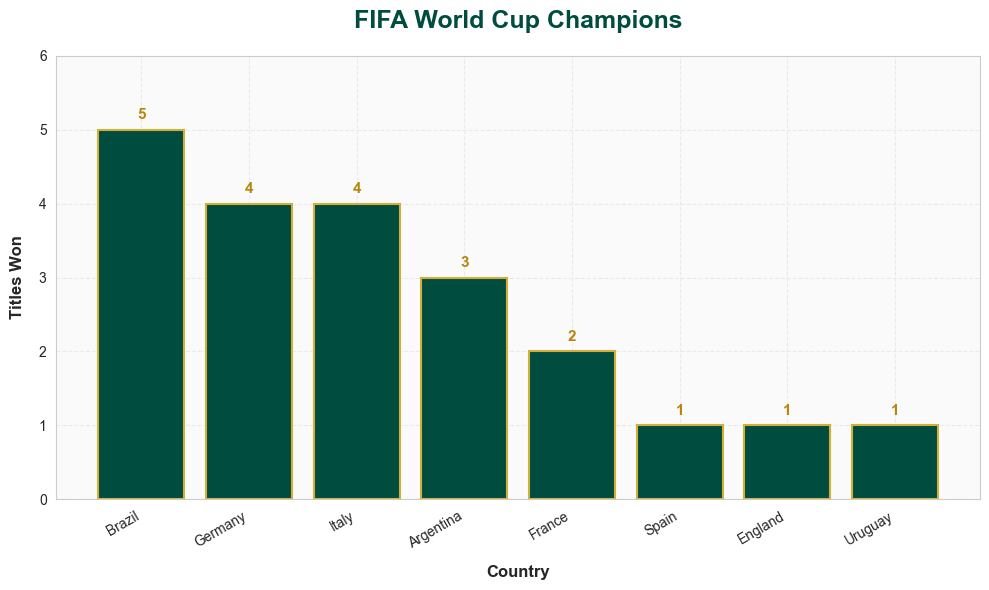

In [21]:
final_matches = df[df['Round'] == 'Final']
winner_counts = final_matches['winner'].value_counts()

plt.figure(figsize=(10, 6))

sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA','grid.color': '#EAEAEA', 'grid.linestyle': '--'})


bars = plt.bar(winner_counts.index, winner_counts.values, color='#004D40', edgecolor='#D4AF37', linewidth=1.5)

plt.title('FIFA World Cup Champions', fontsize=18, fontweight='bold', pad=20, color='#004D40')
plt.xlabel('Country', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Titles Won', fontsize=12, fontweight='bold', labelpad=10)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.1, int(yval), 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#B8860B')

plt.yticks(range(0, int(winner_counts.max()) + 2))
plt.xticks(rotation=30, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

Dominance of the Elite: Brazil, Italy, and Germany/West Germany form the historic "big three" of world football, combination-heavy holding over half of all available World Cup titles.

The Continental Divide: Every single World Cup champion has come exclusively from either Europe or South America, highlighting a historical duopoly in footballing infrastructure and elite talent development that other regions have yet to break.

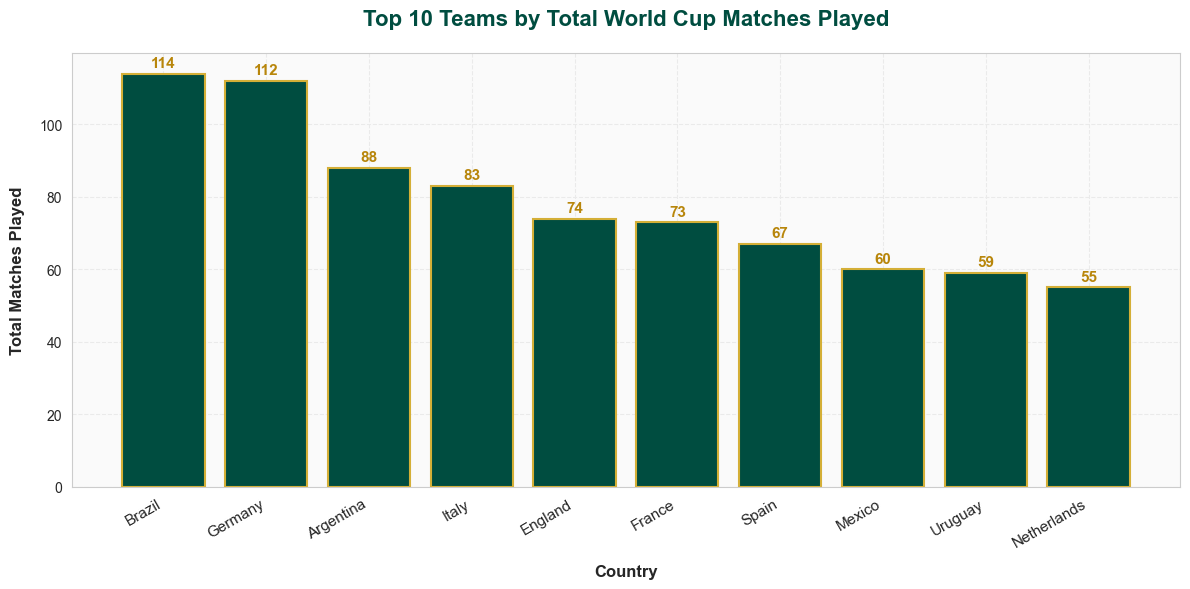

In [22]:
all_teams = pd.concat([df['home_team'], df['away_team']])
top_10_teams = all_teams.value_counts().head(10)

plt.figure(figsize=(12, 6))

sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA', 'grid.color': '#EAEAEA', 'grid.linestyle': '--'})

bars = plt.bar(top_10_teams.index, top_10_teams.values, color='#004D40', edgecolor='#D4AF37', linewidth=1.5)

plt.title('Top 10 Teams by Total World Cup Matches Played', fontsize=16, fontweight='bold', pad=20, color='#004D40')
plt.xlabel('Country', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Total Matches Played', fontsize=12, fontweight='bold', labelpad=10)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, int(yval), 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#B8860B')

# Rotate labels so they don't overlap
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.tight_layout()

plt.show()

Consistency Breeds Success: The teams with the highest number of matches played correspond directly with the teams that have won the most titles (Brazil, Germany, Argentina, Italy).

Deep Tournament Runs: To rack up this many matches, these countries aren't just qualifying for the World Cup; they are consistently reaching the semi-finals and finals, maximizing their appearances across eras.

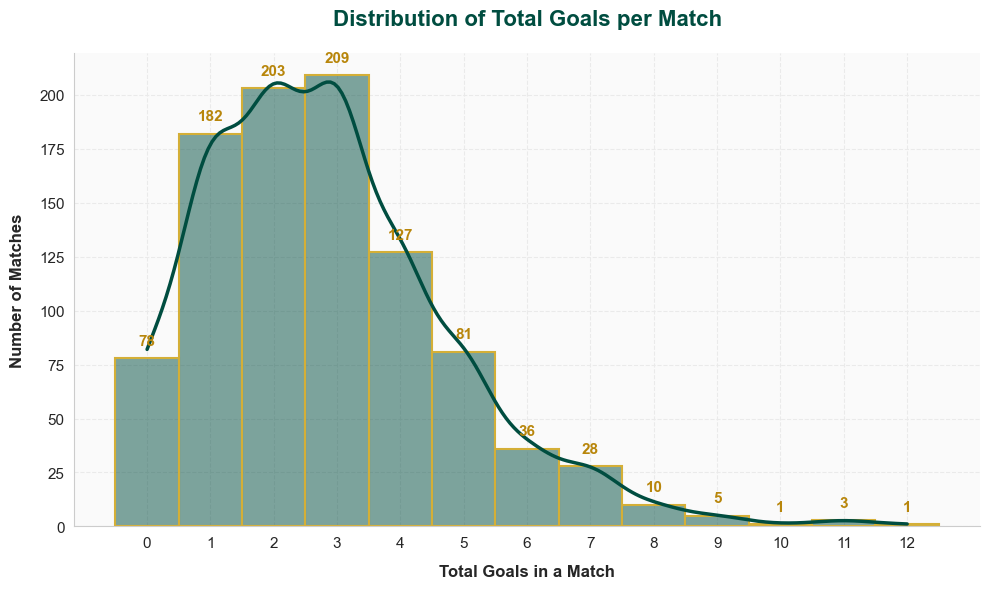

In [23]:
plt.figure(figsize=(10, 6))


sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA','grid.color': '#EAEAEA', 'grid.linestyle': '--'})

ax = sns.histplot(data=df, x='total_goals', discrete=True, color='#004D40', edgecolor='#D4AF37', linewidth=1.5,kde=True, line_kws={'color': '#D4AF37', 'linewidth': 2.5})


plt.title('Distribution of Total Goals per Match', fontsize=16, fontweight='bold', pad=20, color='#004D40')
plt.xlabel('Total Goals in a Match', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Number of Matches', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(range(0, int(df['total_goals'].max()) + 1), fontsize=11)
plt.yticks(fontsize=11)

sns.despine()

for bar in ax.patches:
    yval = bar.get_height()
    if yval > 0:  
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (df['total_goals'].count() * 0.005), f"{int(yval)}", 
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='#B8860B')

plt.tight_layout()
plt.show()

The "Sweet Spot" of Football: The data is heavily concentrated around 2 to 4 goals per match, which represents the most common scoring environment for a standard international fixture.

Outliers are Rare: Matches with 0–1 goals or explosive scorelines of 6+ goals are statistical anomalies, showing that professional tactical setups usually keep games relatively competitive and balanced.

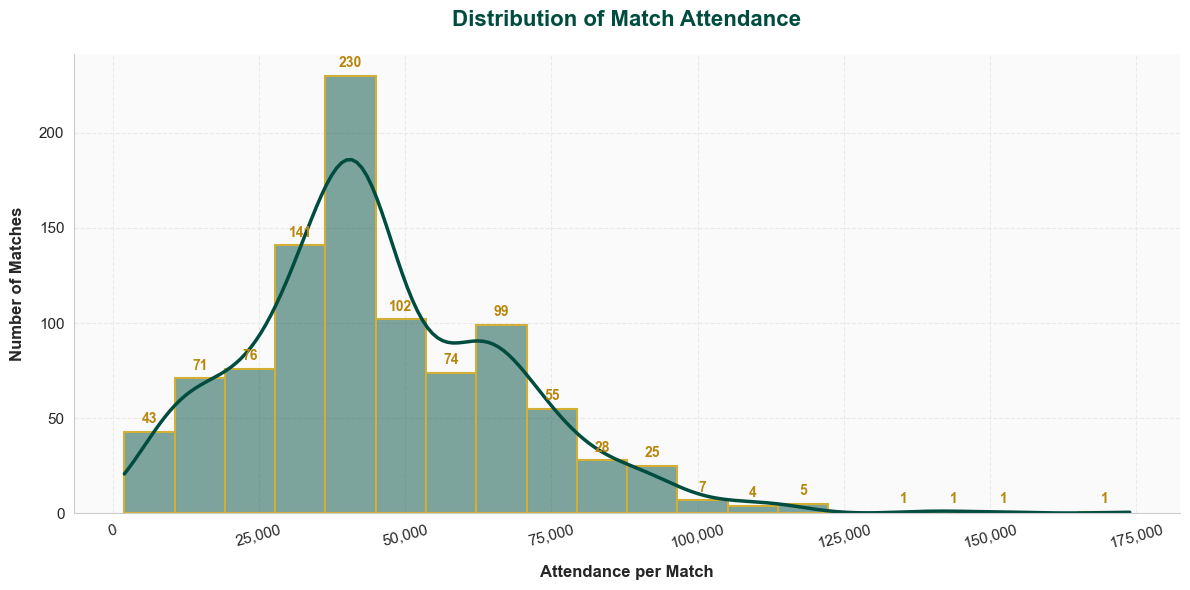

In [24]:
from matplotlib import ticker
plt.figure(figsize=(12, 6))

sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA',  'grid.color': '#EAEAEA','grid.linestyle': '--'})

ax = sns.histplot(data=df, x='Attendance', bins=20, color='#004D40', edgecolor='#D4AF37', linewidth=1.5, kde=True, line_kws={'color': '#D4AF37', 'linewidth': 2.5})

plt.title('Distribution of Match Attendance', fontsize=16, fontweight='bold', pad=20, color='#004D40')
plt.xlabel('Attendance per Match', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Number of Matches', fontsize=12, fontweight='bold', labelpad=10)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(rotation=15, fontsize=11)
plt.yticks(fontsize=11)
sns.despine()

for bar in ax.patches:
    yval = bar.get_height()
    if yval > 0:  
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (df['Attendance'].count() * 0.003), f"{int(yval)}", 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#B8860B')

plt.tight_layout()
plt.show()

The Typical Crowd Size: The overwhelming majority of World Cup matches see a massive cluster of attendance between 30,000 and 50,000 spectators per match. This represents the sweet spot for standard stadium capacities across most host nations.

The "Mega-Match" Outliers: The plot highlights a long tail extending all the way out past 100,000 and even near 175,000 spectators. These rare, massive spikes represent historic outlier events—such as iconic matches played at monumental venues like the Maracanã in Brazil or the Azteca in Mexico—where stadium capacities far exceeded modern safety caps.

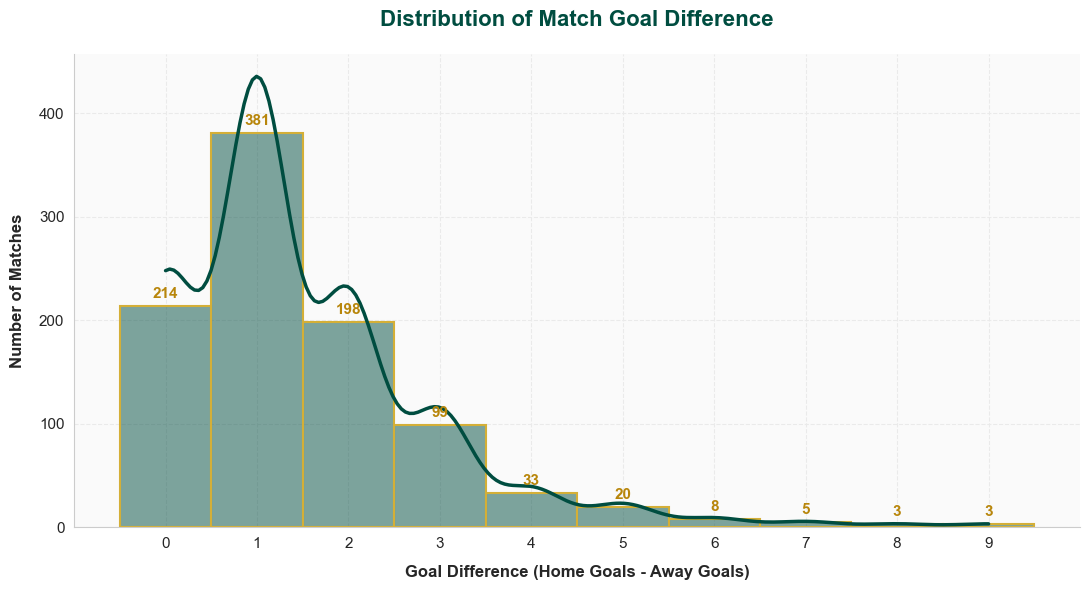

In [25]:
plt.figure(figsize=(11, 6))

sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA','grid.color': '#EAEAEA', 'grid.linestyle': '--' })

ax = sns.histplot(data=df, x='goal_difference', discrete=True, color='#004D40', edgecolor='#D4AF37', linewidth=1.5, kde=True, line_kws={'color': '#D4AF37', 'linewidth': 2.5})

plt.title('Distribution of Match Goal Difference', fontsize=16, fontweight='bold', pad=20, color='#004D40')
plt.xlabel('Goal Difference (Home Goals - Away Goals)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Number of Matches', fontsize=12, fontweight='bold', labelpad=10)

min_gd = int(df['goal_difference'].min())
max_gd = int(df['goal_difference'].max())
plt.xticks(range(min_gd, max_gd + 1), fontsize=11)
plt.yticks(fontsize=11)

sns.despine()

for bar in ax.patches:
    yval = bar.get_height()
    if yval > 0:  
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (df['goal_difference'].count() * 0.005), f"{int(yval)}", 
                 ha='center', va='bottom', fontsize=11, fontweight='bold', color='#B8860B')

plt.tight_layout()
plt.show()

Competitive Parity: The massive spike at a 1-goal or 2-goal difference proves that the vast majority of World Cup matches are tightly contested, high-stakes affairs where one mistake separates winners from losers.

Blowouts are Historic Exceptions: Goal differences exceeding 4 goals are incredibly rare, usually occurring in early group stages when an elite superpower draws a significantly lower-ranked qualifying nation.

## Bivariate Analysis

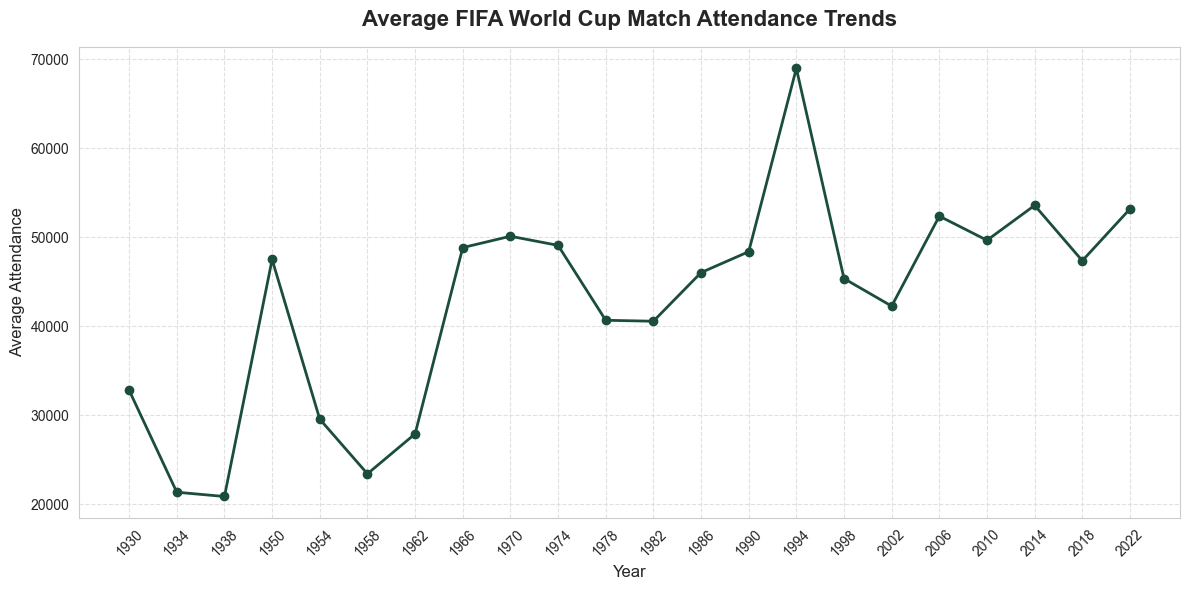

In [26]:
df_yearly = df.groupby('Year')['Attendance'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid", {'grid.color': '#E0E0E0', 'grid.linestyle': '--'})

plt.plot(df_yearly['Year'].astype(str), df_yearly['Attendance'], color='#1B4D3E', marker='o', linewidth=2)

plt.title('Average FIFA World Cup Match Attendance Trends', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Attendance', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The Modern Explosion (Post-1990): The line graph shows a massive, permanent upward shift in attendance beginning in 1994. The 1994 World Cup in the United States remains the absolute peak in history, proving how massive stadium capacities can permanently change tournament metrics.

The Infrastructure Shift (Pre-1966): The early decades (1930–1962) show highly volatile and lower average attendance figures. This reflects an era before modern stadium regulations, ease of international commercial travel, and globalized ticketing systems were fully established

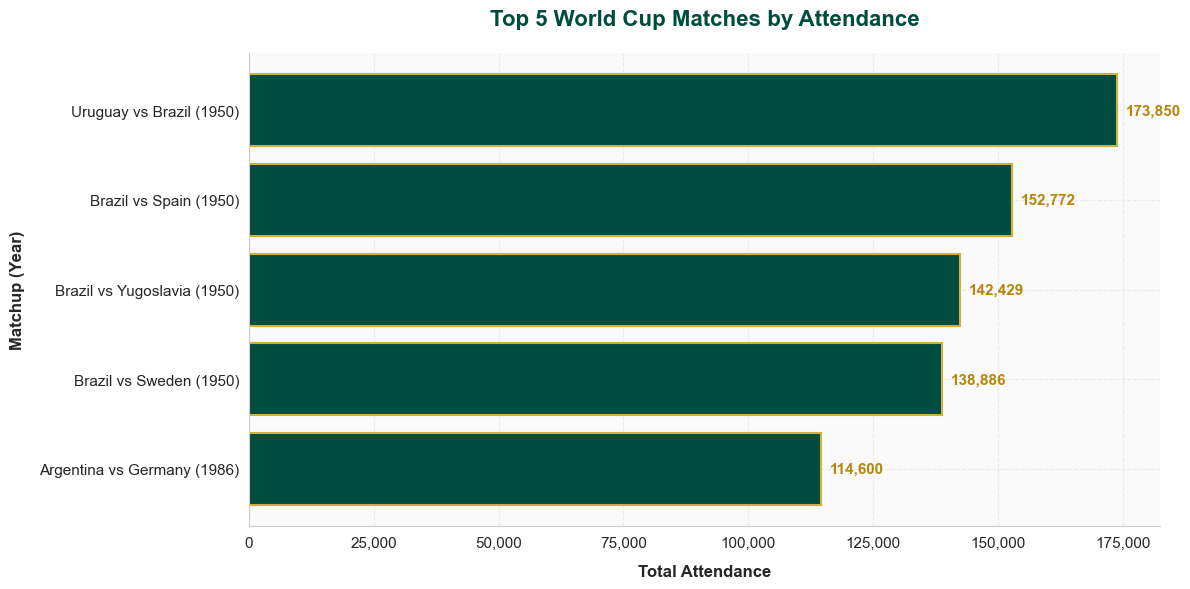

In [27]:
df['Matchup'] = df['home_team'] + ' vs ' + df['away_team'] + ' (' + df['Year'].astype(str) + ')'
top_5_attendance = df.nlargest(5, 'Attendance')

plt.figure(figsize=(12, 6))

sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA', 'grid.color': '#EAEAEA', 'grid.linestyle': '--'  })

bars = plt.barh(top_5_attendance['Matchup'], top_5_attendance['Attendance'], 
                color='#004D40', edgecolor='#D4AF37', linewidth=1.5)

plt.title('Top 5 World Cup Matches by Attendance', fontsize=16, fontweight='bold', pad=20, color='#004D40')
plt.xlabel('Total Attendance', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Matchup (Year)', fontsize=12, fontweight='bold', labelpad=10)

plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.gca().invert_yaxis()

sns.despine()

for bar in bars:
    xval = bar.get_width()
    plt.text(xval + (top_5_attendance['Attendance'].max() * 0.01), 
             bar.get_y() + bar.get_height()/2.0, 
             f"{int(xval):,}", 
             ha='left', va='center', fontsize=11, fontweight='bold', color='#B8860B')

plt.tight_layout()
plt.show()

The Absolute Peak (The Historic Outliers): The chart shows a massive cluster of matches from 1950 taking the top spots, dominated heavily by matches held in Brazil (like the legendary matchups at the Maracanã). These historical matches drew spectacular, unrepeated crowds pushing past 135,000 to over 173,000 fans.

The Modern vs. Historical Cap: The entry from 1986 (Argentina vs. West Germany at the Estadio Azteca) stands out as a more modern peak. This visual shift illustrates how older tournaments could fit staggering, massive numbers of standing spectators, whereas modern World Cup matches are strictly capped by all-seater stadium safety configurations.

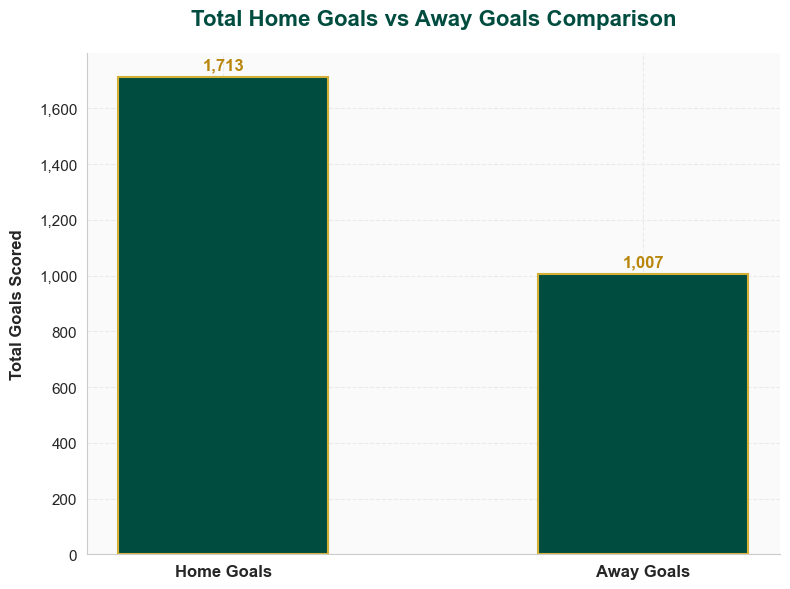

In [28]:
total_home_goals = df['home_score'].sum()
total_away_goals = df['away_score'].sum()

categories = ['Home Goals', 'Away Goals']
values = [total_home_goals, total_away_goals]

plt.figure(figsize=(8, 6))

sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA', 'grid.color': '#EAEAEA', 'grid.linestyle': '--'})


bars = plt.bar(categories, values, color='#004D40', edgecolor='#D4AF37', linewidth=1.5, width=0.5)

plt.title('Total Home Goals vs Away Goals Comparison', fontsize=16, fontweight='bold', pad=20, color='#004D40')
plt.ylabel('Total Goals Scored', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=11)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

sns.despine()

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(values) * 0.01), f"{int(yval):,}", 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='#B8860B')

plt.tight_layout()
plt.show()

In [29]:
df['is_actual_host'] = df['home_team'] == df['Host']

print("Avg goals when the Home team is the ACTUAL host:")
print(df[df['is_actual_host'] == True]['home_score'].mean())

print("\nAvg goals when the Home team is just administratively 'Home':")
print(df[df['is_actual_host'] == False]['home_score'].mean())

print("\nAvg goals scored by the Away team (Neutral/Visitor):")
print(df['away_score'].mean())

print('--'*70)

Avg goals when the Home team is the ACTUAL host:
2.107142857142857

Avg goals when the Home team is just administratively 'Home':
1.7454545454545454

Avg goals scored by the Away team (Neutral/Visitor):
1.0446058091286308
--------------------------------------------------------------------------------------------------------------------------------------------


The Myth of the "Away" Disadvantage: The massive gap between total Home and Away goals in World Cup history is not a coincidence, but it is also not a traditional home-field advantage for most teams. Instead, it is driven by two distinct factors:

True Host Domination: Actual host nations score an incredible 2.10 goals per match due to crowd energy and familiar environments.

Administrative Seeding Bias: For all other matches on neutral ground, FIFA's scheduling systematically assigns the stronger, top-seeded team to the "Home" slot. This causes the administrative "Home" teams to outscore "Away" teams (1.75 vs 1.04) simply because the stronger team is wearing the "Home" tag.

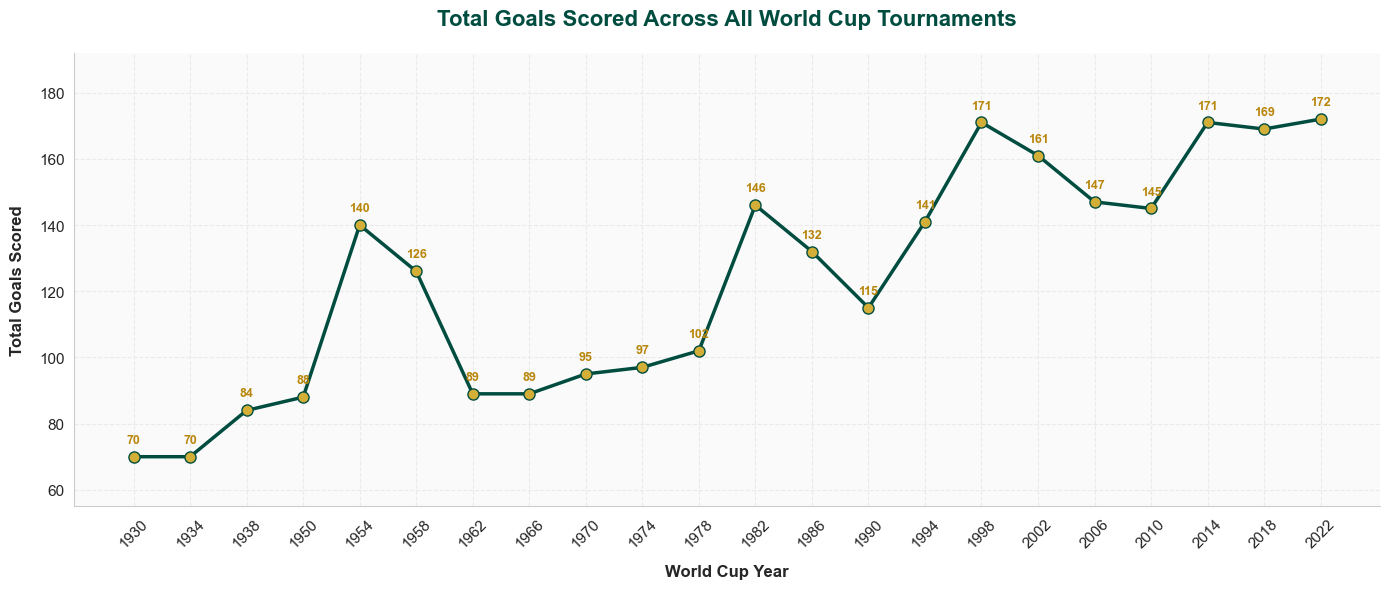

In [30]:
goals_per_wc = df.groupby('Year')['total_goals'].sum().reset_index().sort_values('Year')
goals_per_wc['Year'] = goals_per_wc['Year'].astype(str)

plt.figure(figsize=(14, 6))

sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA', 'grid.color': '#EAEAEA', 'grid.linestyle': '--'})

plt.plot(goals_per_wc['Year'], goals_per_wc['total_goals'], color='#004D40', linewidth=2.5, marker='o', markerfacecolor='#D4AF37', markeredgecolor='#004D40', markersize=8)

plt.title('Total Goals Scored Across All World Cup Tournaments', fontsize=16, fontweight='bold', pad=20, color='#004D40')
plt.xlabel('World Cup Year', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Total Goals Scored', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)

sns.despine()

for i, txt in enumerate(goals_per_wc['total_goals']):
    plt.annotate(f"{int(txt)}", 
                 (goals_per_wc['Year'].iloc[i], goals_per_wc['total_goals'].iloc[i]),
                 textcoords="offset points", 
                 xytext=(0, 10), 
                 ha='center', 
                 fontsize=9, 
                 fontweight='bold', 
                 color='#B8860B')

plt.ylim(goals_per_wc['total_goals'].min() - 15, goals_per_wc['total_goals'].max() + 20)

plt.tight_layout()
plt.show()

The Expansion Effect: There is a massive, permanent upward shift in total goals starting in 1998 (climbing from the 110–140 range up to the 160–170+ range). This isn't necessarily because teams suddenly became better at scoring; it's because the tournament expanded from 24 teams to 32 teams in 1998, dramatically increasing the total number of matches played from 52 to 64.

The Modern Plateaus: The peaks in 1998 (171 goals), 2014 (171 goals), and 2022 (172 goals) show that under the 32-team format, ~170 goals represents the absolute ceiling for an ultra-high-scoring modern tournament.

The 1954 Anomaly: Look at the massive spike in 1954 (140 goals). What makes this incredible is that it happened when the tournament only had 16 teams and played just 26 total matches! This highlights the wild, hyper-offensive tactical era of the 1950s compared to the tightly structured defensive systems of the modern era.

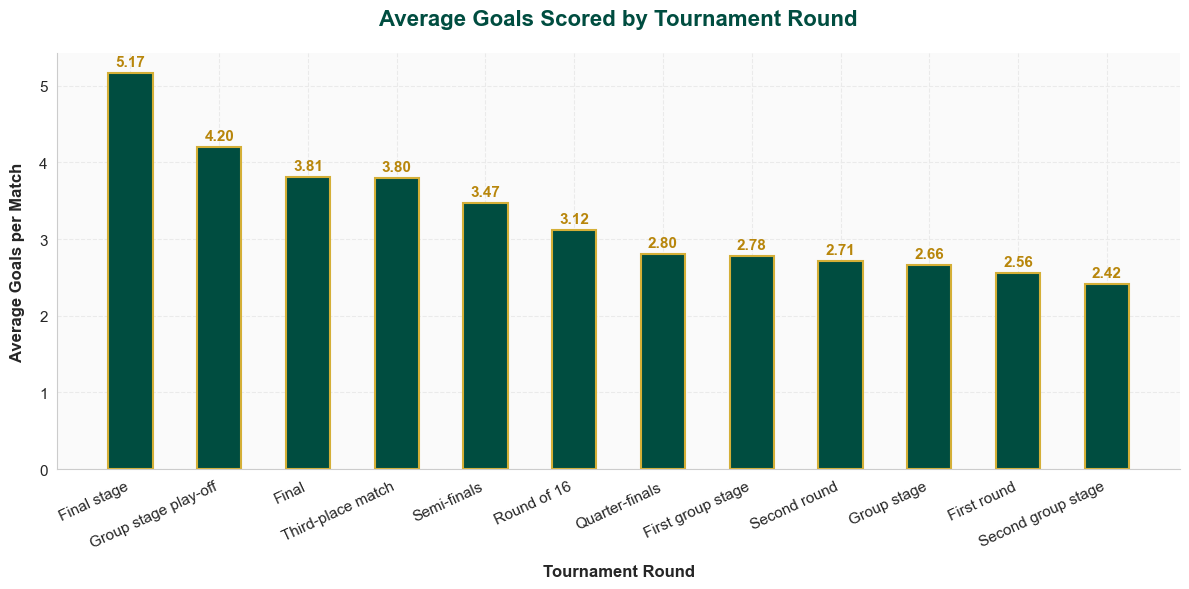

In [31]:
avg_goals_round = df.groupby('Round')['total_goals'].mean().reset_index()

avg_goals_round = avg_goals_round.sort_values('total_goals', ascending=False)

plt.figure(figsize=(12, 6))

sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA', 'grid.color': '#EAEAEA', 'grid.linestyle': '--'})

bars = plt.bar(avg_goals_round['Round'], avg_goals_round['total_goals'], color='#004D40', edgecolor='#D4AF37', linewidth=1.5, width=0.5)

plt.title('Average Goals Scored by Tournament Round', fontsize=16, fontweight='bold', pad=20, color='#004D40')
plt.xlabel('Tournament Round', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Average Goals per Match', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(rotation=25, ha='right', fontsize=11)
plt.yticks(fontsize=11)

sns.despine()

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (avg_goals_round['total_goals'].max() * 0.01), 
             f"{yval:.2f}", ha='center', va='bottom', fontsize=11, fontweight='bold', color='#B8860B')

plt.tight_layout()
plt.show()

The 1950 Round-Robin Anomaly (Final Stage - 5.17 goals): This category sits at the absolute top of the chart because of a unique historical format change. The 1950 World Cup featured a 4-team round-robin group instead of a knockout bracket. Because this represents multiple matches played during a historically high-scoring era, it artificially inflates this specific round label.

The True Championship Baseline (Final - 3.81 goals): When looking at standard, single-elimination modern finals, the average sits at a healthy 3.81 goals per match. While lower than the 1950 anomaly, this still proves that the ultimate match of the tournament produces plenty of goals and rarely turns into a boring defensive stalemate.

The Consolation Entertainment (Third-place match - 3.80 goals): The bronze-medal match closely mirrors the true finals. Because the ultimate pressure of winning the trophy is gone, both teams play highly open, expressive, and entertaining attacking football.

The Knockout Tightening Effect: As you move down from the Semi-finals (3.47) to the Round of 16 (3.12) and Quarter-finals (2.80), you see standard tournament tension at work. The closer teams get to the final, the more defensively structured and cautious their tactics become to avoid a costly elimination mistake.

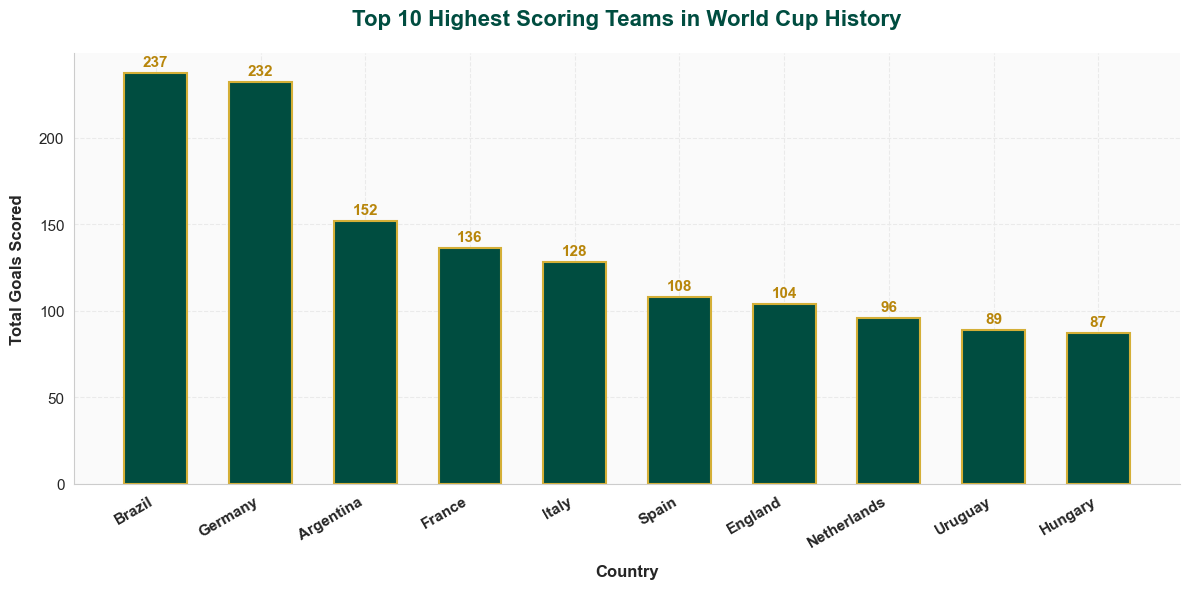

In [32]:
home_goals = df.groupby('home_team')['home_score'].sum()
away_goals = df.groupby('away_team')['away_score'].sum()

total_goals_per_team = home_goals.add(away_goals, fill_value=0)
top_10_scoring_teams = total_goals_per_team.nlargest(10).reset_index()
top_10_scoring_teams.columns = ['Team', 'Total_Goals']

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA', 'grid.color': '#EAEAEA', 'grid.linestyle': '--'})

bars = plt.bar(top_10_scoring_teams['Team'], top_10_scoring_teams['Total_Goals'], color='#004D40', edgecolor='#D4AF37', linewidth=1.5, width=0.6)

plt.title('Top 10 Highest Scoring Teams in World Cup History', fontsize=16, fontweight='bold', pad=20, color='#004D40')
plt.xlabel('Country', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Total Goals Scored', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(rotation=30, ha='right', fontsize=11, fontweight='bold')
plt.yticks(fontsize=11)

sns.despine()

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (top_10_scoring_teams['Total_Goals'].max() * 0.01), 
             f"{int(yval)}", ha='center', va='bottom', fontsize=11, fontweight='bold', color='#B8860B')

plt.tight_layout()
plt.show()

The Historic Powerhouses: Teams like Brazil and Germany heavily lead this chart. This is a direct reflection of two things: their incredible offensive longevity across decades, and their ability to consistently make deep tournament runs (maximizing the number of games played to rack up goals).

European and South American Dominance: The top 10 is exclusively occupied by teams from these two continents, highlighting where the historical monopoly of elite goal-scoring talent resides.

## Multivariate Analysis

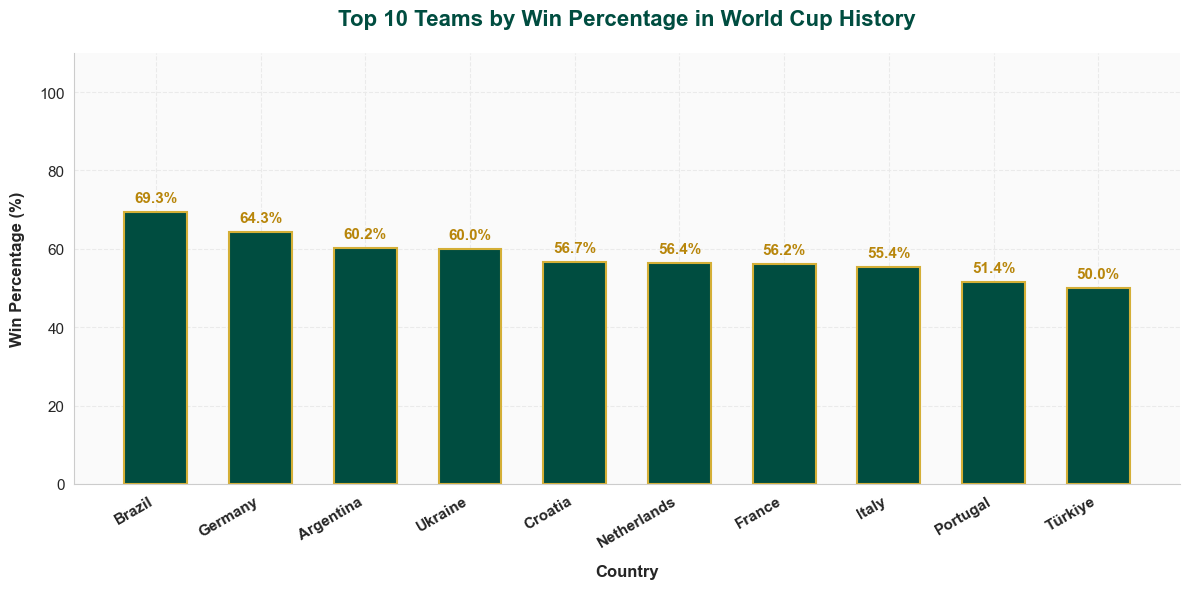

In [33]:
all_matches = pd.concat([df['home_team'], df['away_team']])
total_matches = all_matches.value_counts()

total_wins = df[~df['winner'].isin(['Draw', 'Tie', 'draw'])]['winner'].value_counts()
stats = pd.DataFrame({'Wins': total_wins, 'Matches': total_matches}).fillna(0)
stats = stats[stats['Matches'] >= 5] 

stats['Win_Percentage'] = (stats['Wins'] / stats['Matches']) * 100
top_10_win_pct = stats.nlargest(10, 'Win_Percentage').reset_index()
top_10_win_pct.columns = ['Team', 'Wins', 'Matches', 'Win_Percentage']

plt.figure(figsize=(12, 6))

sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA', 'grid.color': '#EAEAEA', 'grid.linestyle': '--'})

ax = plt.gca()
plt.bar(top_10_win_pct['Team'], top_10_win_pct['Win_Percentage'], color='#004D40', edgecolor='#D4AF37', linewidth=1.5, width=0.6)

plt.title('Top 10 Teams by Win Percentage in World Cup History', fontsize=16, fontweight='bold', pad=20, color='#004D40')
plt.xlabel('Country', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Win Percentage (%)', fontsize=12, fontweight='bold', labelpad=10)

plt.xticks(rotation=30, ha='right', fontsize=11, fontweight='bold')
plt.yticks(fontsize=11)
plt.ylim(0, 110) 

sns.despine()

ax.bar_label(ax.containers[0], fmt='%.1f%%', label_type='edge', padding=5, color='#B8860B', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Efficiency vs. Longevity: This graph highlights true efficiency. While a team might play fewer historical matches than a giant like Brazil or Germany, their high win percentage proves that when they do qualify, they are lethal and consistently secure victories rather than settling for draws or losses.

The Elite Threshold: Maintaining a win percentage well above 50% in a tournament as fiercely contested as the World Cup is incredibly difficult and separates the true title contenders from casual qualifiers.

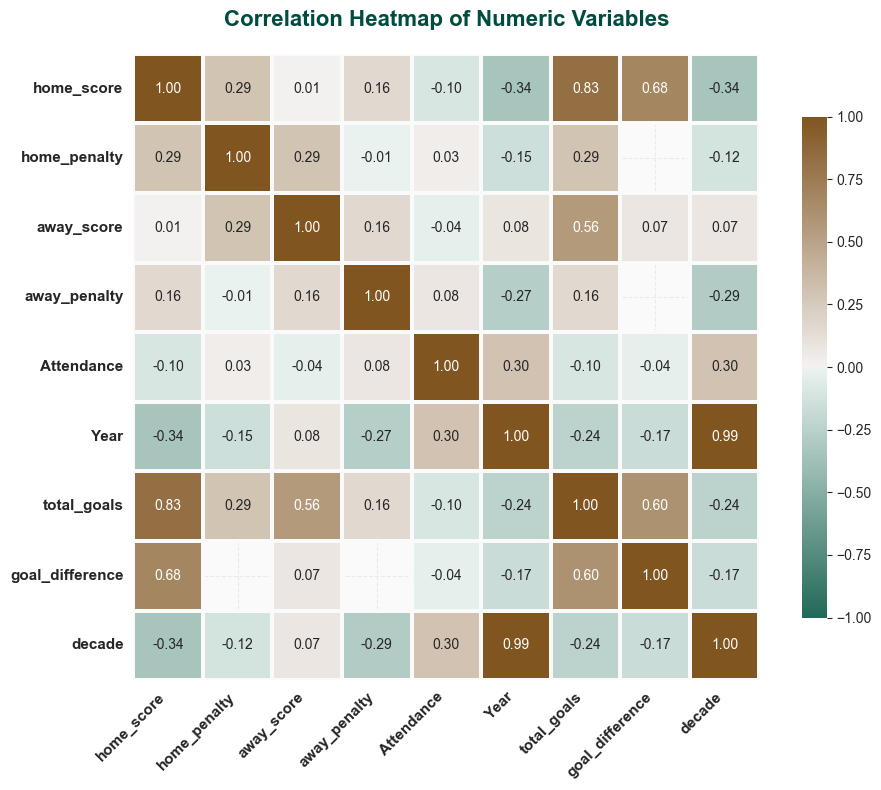

In [34]:
numeric_df = df.select_dtypes(include=['number'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

sns.set_style("whitegrid", {'axes.facecolor': '#FAFAFA', 'grid.color': '#EAEAEA', 'grid.linestyle': '--'})

cmap = sns.diverging_palette(165, 45, s=85, l=40, as_cmap=True)

ax = sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=cmap, vmin=-1, vmax=1, square=True, linewidths=1.5, linecolor='#FAFAFA', cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap of Numeric Variables', fontsize=16, fontweight='bold', pad=20, color='#004D40')

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.yticks(rotation=0, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Home Field Advantage Rules: The incredibly high correlation between total_goals and home_score (0.83) compared to away_score (0.56) demonstrates that high-scoring, exciting games are heavily dictated by the offensive output of the designated home team.

Modern Tactical Shifts: The negative correlation between the tournament Year and total_goals explicitly shows that over the decades, World Cups have become slightly lower scoring. Football has evolved from the high-scoring, open play styles of the 1950s into highly disciplined, defensively structured modern systems

## Hypothesis Testing
Checking whether host teams score more goals than non host teams

In [35]:
from scipy import stats

host_matches = df[df['home_team'] == df['Host']]
host_goals = host_matches['home_score']

non_host_home = df[df['home_team'] != df['Host']]['home_score']
non_host_away = df[df['away_team'] != df['Host']]['away_score']
non_host_goals = pd.concat([non_host_home, non_host_away])

t_stat, p_value = stats.ttest_ind(host_goals, non_host_goals, alternative='greater')

print(f"Host Team Avg Goals: {host_goals.mean():.2f}")
print(f"Non-Host Team Avg Goals: {non_host_goals.mean():.2f}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("\nResult: Reject H0 — Host teams score significantly more than non-host teams")
else:
    print("\nResult: Fail to reject H0 — No significant difference in scoring")

Host Team Avg Goals: 2.11
Non-Host Team Avg Goals: 1.38
T-statistic: 4.6359
P-value: 0.0000

Result: Reject H0 — Host teams score significantly more than non-host teams
